In [1]:
record_file_path = '/mnt/20F408ADF408876E/TCG/TCG_final/wakasagihime/record/record_of_negascout2025-12-28_20-49-42.txt'

with open(record_file_path, 'r') as f:
    content = f.read()


In [4]:
search_depth = []
steps = []
prediction_correctness = []
visited_positions = []
visited_criricals = []
game_info = []

for s in content.split('@'):
    # print(s)
    # print('------------------')
    # s = s.split('\n')
    if len(s) == 0:
        continue
    step = s.split('\n')[0].split('step')[1]
    step = int(step)
    move = None
    rate = None
    depth = None
    vis = None
    vis_critical = None
    for line in s.split('\n'):
        if "optimal move:" in line:
            move = line.replace("optimal move:", "")
            continue
        if "success rate" in line:
            if 'nan' in line:
                continue;
            rate = eval(line.replace('success rate: ', ''))
            continue
        if 'depth' in line:
            depth = eval(line.replace('depth:', ''))
        if 'visited positions:' in line:
            vis = eval(line.replace('visited positions:', ''))
        if 'visited criticals:' in line:
            vis_critical = eval(line.replace('visited criticals:', ''))
    if move is None:
        continue

    # print('move:', move)
    # print('rate:', rate)
    # print('depth:', depth)

    round_info = {
        'depth' : depth,
        'prediction rate': rate,
        'move': move,
        'visited': vis,
        'criticals': vis_critical
    }
    if vis is None:
        print(round_info)
        print(s)
        break

    steps.append(step)
    search_depth.append(depth)
    prediction_correctness.append(rate)
    game_info.append(round_info)
    visited_positions.append(vis - vis_critical)
    visited_criricals.append(vis_critical)



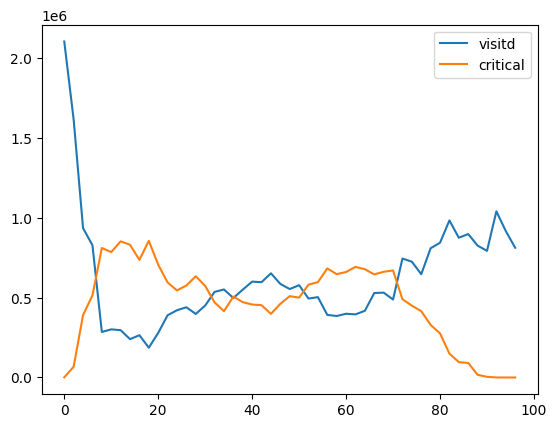

In [6]:
import matplotlib.pyplot as plt
plt.plot(steps, visited_positions, label = 'visitd')
plt.plot(steps, visited_criricals, label = 'critical')
plt.legend()
plt.show()

(0.0, 30.0)

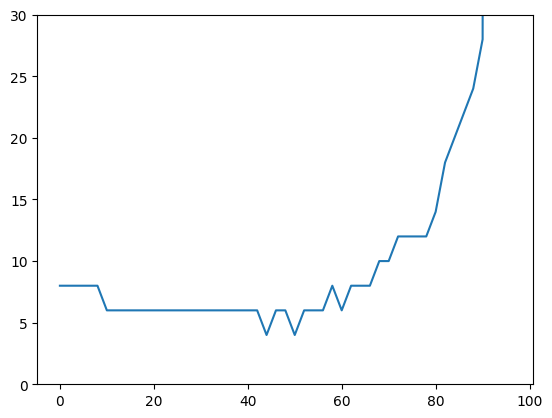

In [7]:
import matplotlib.pyplot as plt
plt.plot(steps, search_depth)
plt.ylim(0, 30)

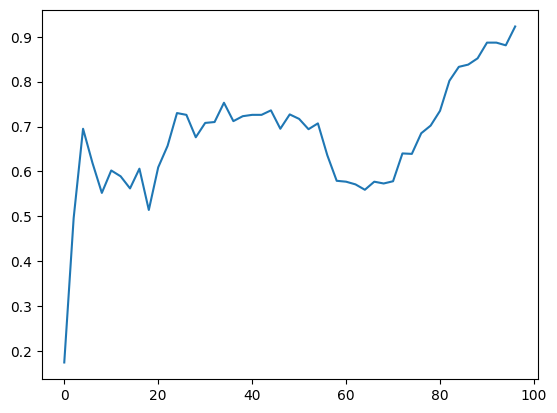

In [8]:
plt.plot(steps, prediction_correctness)
plt.show()